In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def print_multiple_accuracy(run_dirs, labels, title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что выдаем ("train_loss", "test_loss", )
    """
    print(title)

    for run_dir, label in zip(run_dirs, labels):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        # train_acc = data["history"]["train_acc"]
        test_acc = data["history"]["test_acc"]


        print(label)
        # print("train_acc (finish):", train_acc[-1])
        print("test_acc (finish): ", test_acc[-1])
        print('\n')

In [ ]:
def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD", ...])
    metric: что рисуем ("train_loss", "test_loss", ...)
    """

    plt.figure(figsize=(12, 8))

    markers = ["o", "s", "^", "D", "v", "x", "*"] 

    for i, (run_dir, label) in enumerate(zip(run_dirs, labels)):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        history = data["history"]
        values = history[metric]

        epochs = np.arange(1, len(values) + 1)

        history = data["history"]
        values = np.array(history[metric])

        # Находим индексы, где значение меняется
        # (или можно просто взять каждый 100-й элемент, если вы точно знаете шаг)
        change_indices = [0]  # начинаем с первого элемента
        for idx in range(1, len(values)):
            if values[idx] != values[idx - 1]:  # значение изменилось
                change_indices.append(idx)
        
        # Берём только изменённые значения
        changed_values = values[change_indices]
        changed_epochs = np.array(change_indices) + 1  # +1 если epochs с 1, иначе оставить как есть
        
        plt.plot(
            changed_epochs, 
            changed_values, 
        # plt.plot(
        #     epochs, 
        #     values, 
            label=label,
            linewidth=2.5,
            marker=markers[i % len(markers)],
            markersize=7, 
            markevery=len(changed_values)//4,
        )

    metric_names = {
        "train_loss": "Train Loss",
        "test_loss": "Test Loss",
        "train_acc": "Train Accuracy",
        "test_acc": "Test Accuracy",
    }
    ylabel = metric_names.get(metric, metric)
    plt.ylabel(ylabel, fontsize=20)
    plt.xlabel("Rounds", fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    #plt.title(title)
    plt.grid(True)
    plt.legend(fontsize=18)
    plt.tight_layout()
    plt.show()

#  CIFAR10

### Обучение клиентов $\in [1, 3, 5, 7, 9]$ с SignMuon

In [4]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c1_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c5_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c7_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    labels=[
        "signmuon_cl_homo_cnn2_r2000_c1_s1",
        "signmuon_cl_homo_cnn2_r2000_c3_s1",
        "signmuon_cl_homo_cnn2_r2000_c5_s1",
        "signmuon_cl_homo_cnn2_r2000_c7_s1",
        "signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    title="CIFAR10",
)

CIFAR10
signmuon_cl_homo_cnn2_r2000_c1_s1
test_acc (finish):  76.13


signmuon_cl_homo_cnn2_r2000_c3_s1
test_acc (finish):  81.24


signmuon_cl_homo_cnn2_r2000_c5_s1
test_acc (finish):  82.87


signmuon_cl_homo_cnn2_r2000_c7_s1
test_acc (finish):  83.54


signmuon_cl_homo_cnn2_r2000_c9_s1
test_acc (finish):  84.03




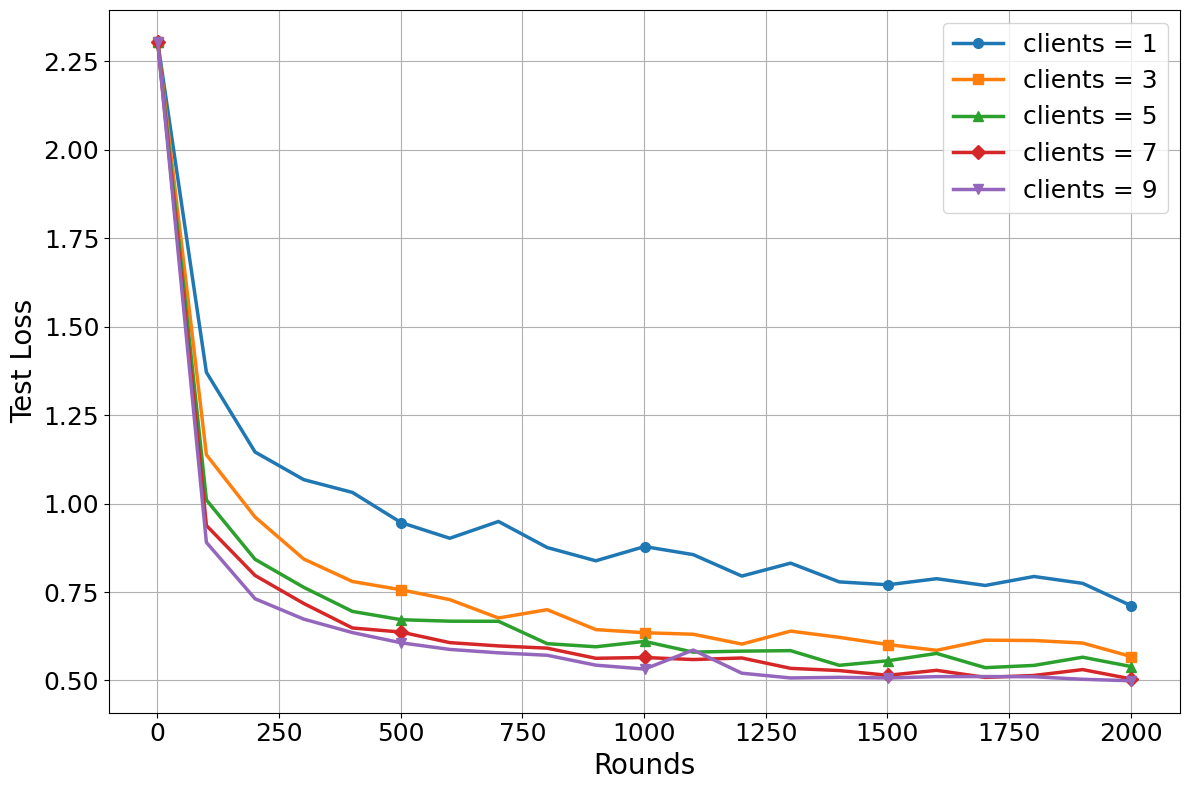

In [5]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c1_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c5_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c7_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    labels=[
        "clients = 1",
        "clients = 3" ,
        "clients = 5",
        "clients = 7",
        "clients = 9"
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

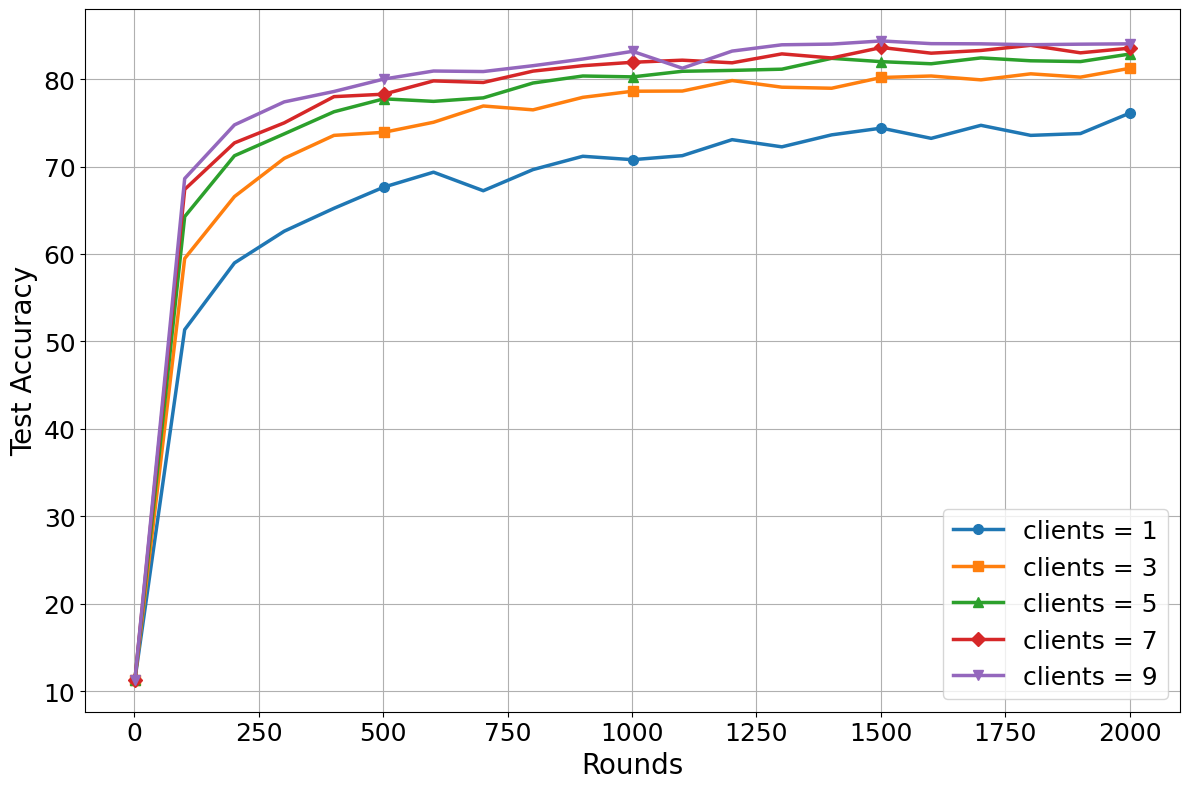

In [6]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c1_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c5_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c7_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c9_s1",
    ],
    labels=[
        "clients = 1",
        "clients = 3" ,
        "clients = 5",
        "clients = 7",
        "clients = 9"
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
)

### Обучение 3 клиентов c шагом 1 с разными алгоритмами

In [7]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "SignMuon_EF",
    ],
    title="CIFAR10",
)

CIFAR10
SignMuon
test_acc (finish):  81.24


Muon
test_acc (finish):  81.27


SignSGD
test_acc (finish):  65.96


SGD
test_acc (finish):  76.77000000000001


Adam
test_acc (finish):  70.83


SignMuon_EF
test_acc (finish):  75.92




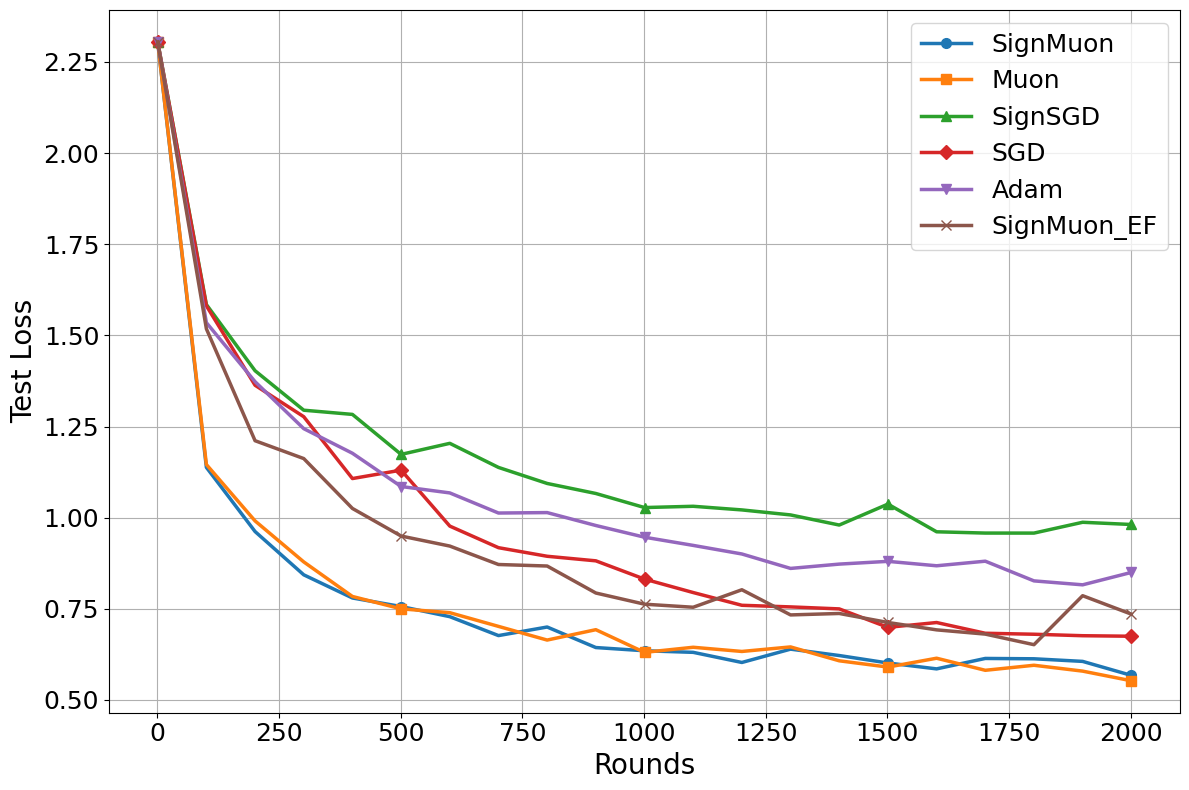

In [8]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "SignMuon_EF",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

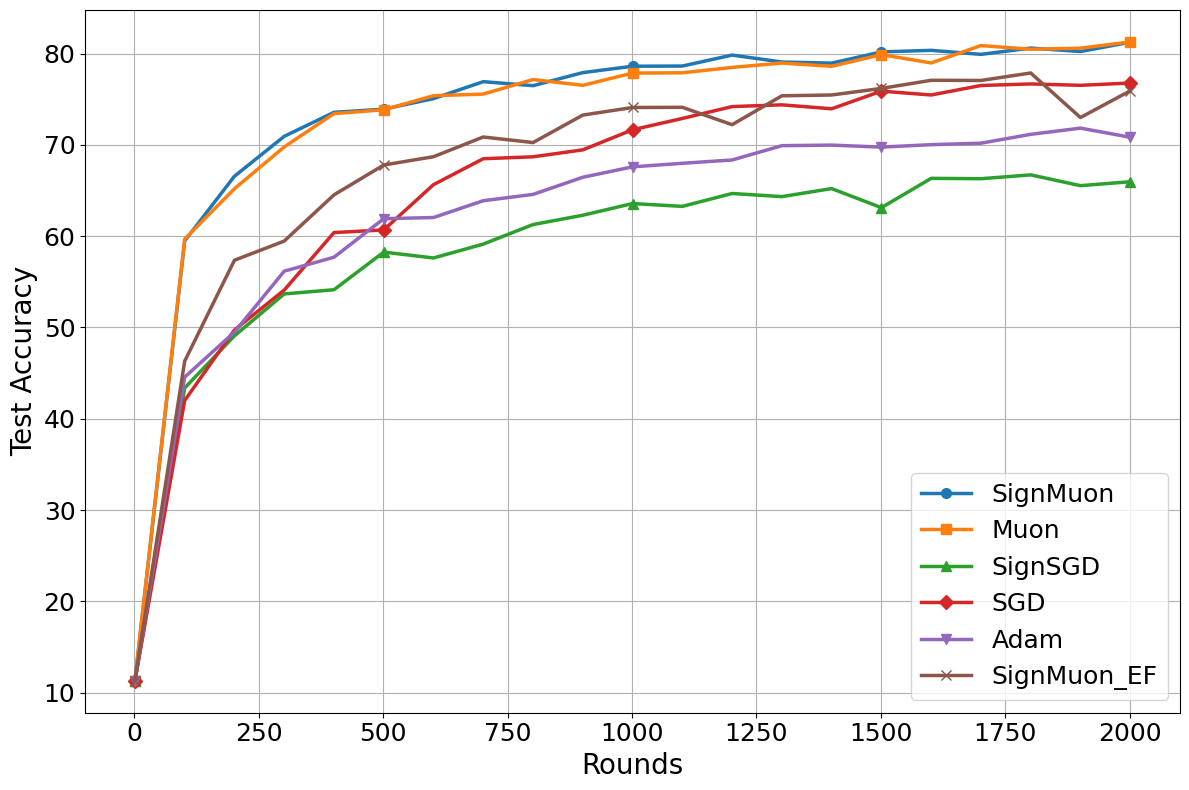

In [9]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c3_s1",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "SignMuon_EF",
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
)

### Обучение 10 клиентов шагом 3 с разными алгоритмами

In [10]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "SignMuon_EF",
    ],
    title="CIFAR10",
)

CIFAR10
SignMuon
test_acc (finish):  84.57000000000001


Muon
test_acc (finish):  85.22


SignSGD
test_acc (finish):  78.97999999999999


SGD
test_acc (finish):  81.38


Adam
test_acc (finish):  78.36


SignMuon_EF
test_acc (finish):  82.31




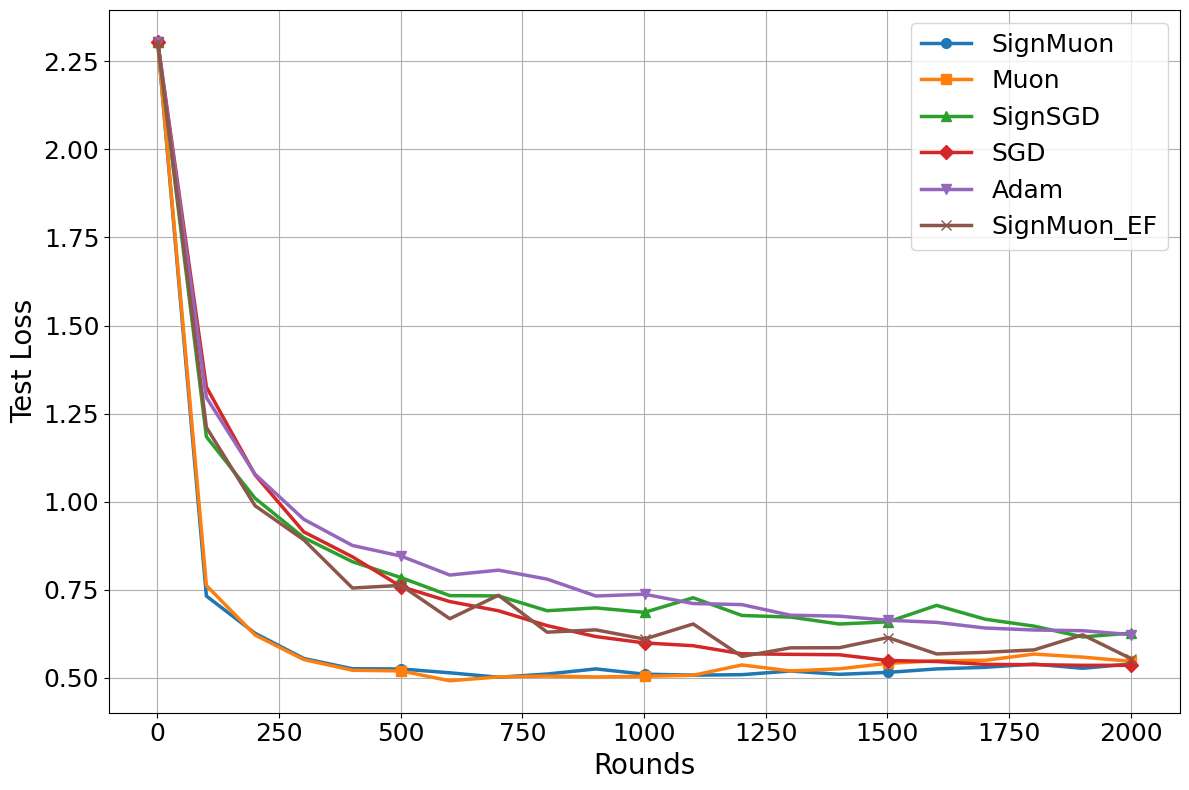

In [11]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "SignMuon_EF",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

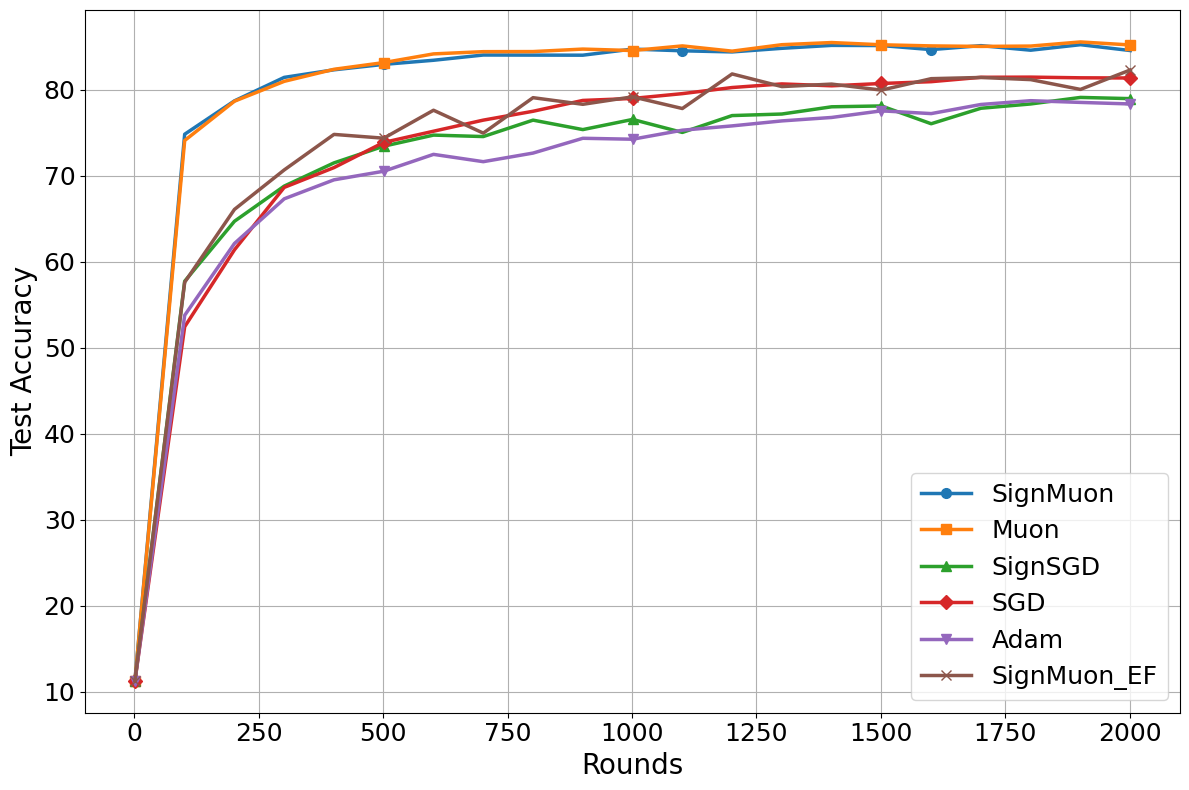

In [12]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_cl_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_muon_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_signsgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_sgd_homo_cnn2_r2000_c10_s3",
        "saves_federated/v2_correct_moment/fed_cifar10_adam_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "SignMuon_EF",
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
)

### Сравнение EF и EF_21


In [13]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "SignMuon_EF",
        "SignMuon_EF_21",
    ],
    title="CIFAR10",
)

CIFAR10
SignMuon_EF
test_acc (finish):  73.36


SignMuon_EF_21
test_acc (finish):  75.92




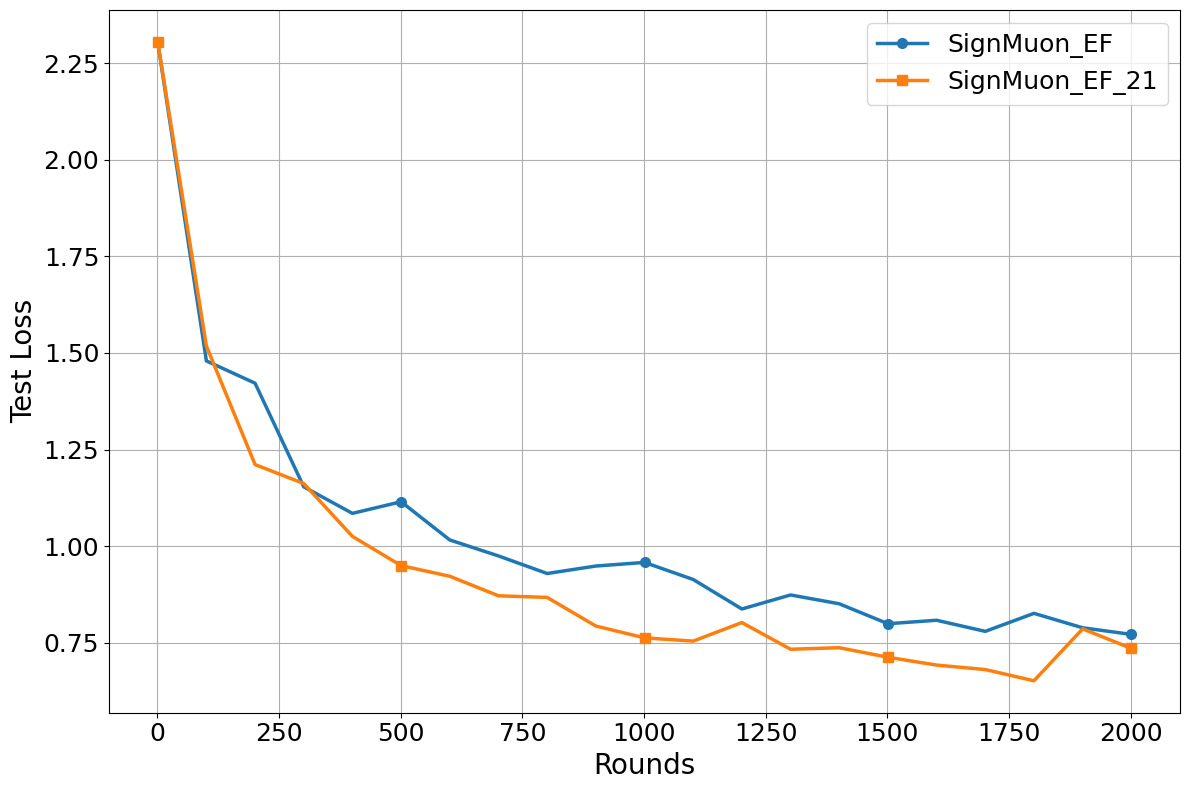

In [14]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "SignMuon_EF",
        "SignMuon_EF_21",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

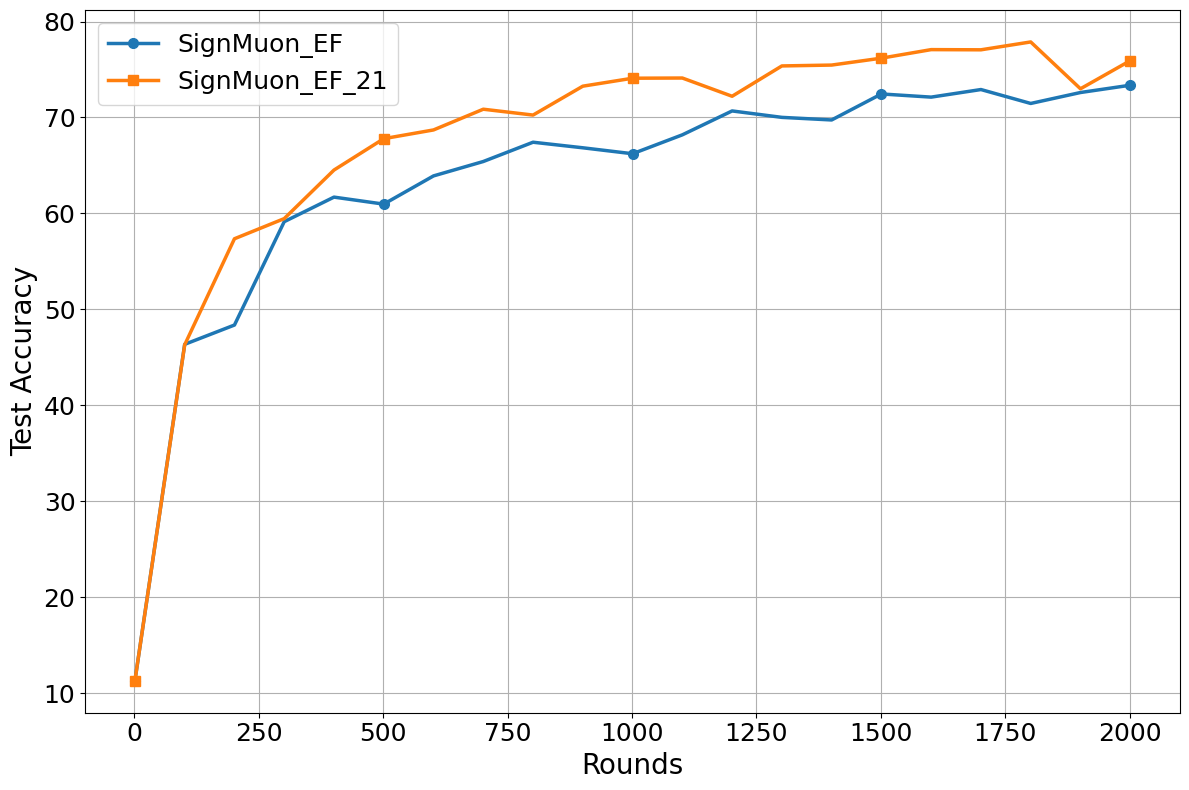

In [15]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c3_s1",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c3_s1",
    ],
    labels=[
        "SignMuon_EF",
        "SignMuon_EF_21",
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
)

In [16]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "SignMuon_EF",
        "SignMuon_EF_21",
    ],
    title="CIFAR10",
)

CIFAR10
SignMuon_EF
test_acc (finish):  78.38000000000001


SignMuon_EF_21
test_acc (finish):  82.31




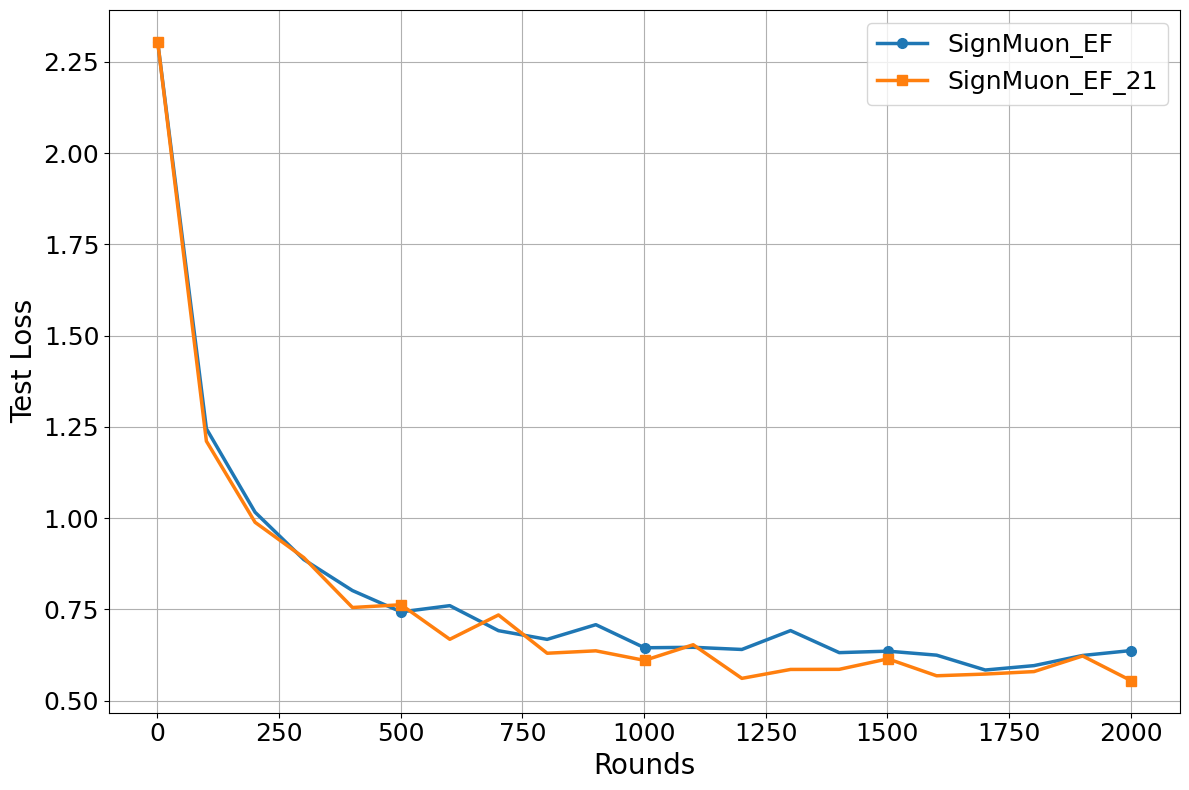

In [17]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "SignMuon_EF",
        "SignMuon_EF_21",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)

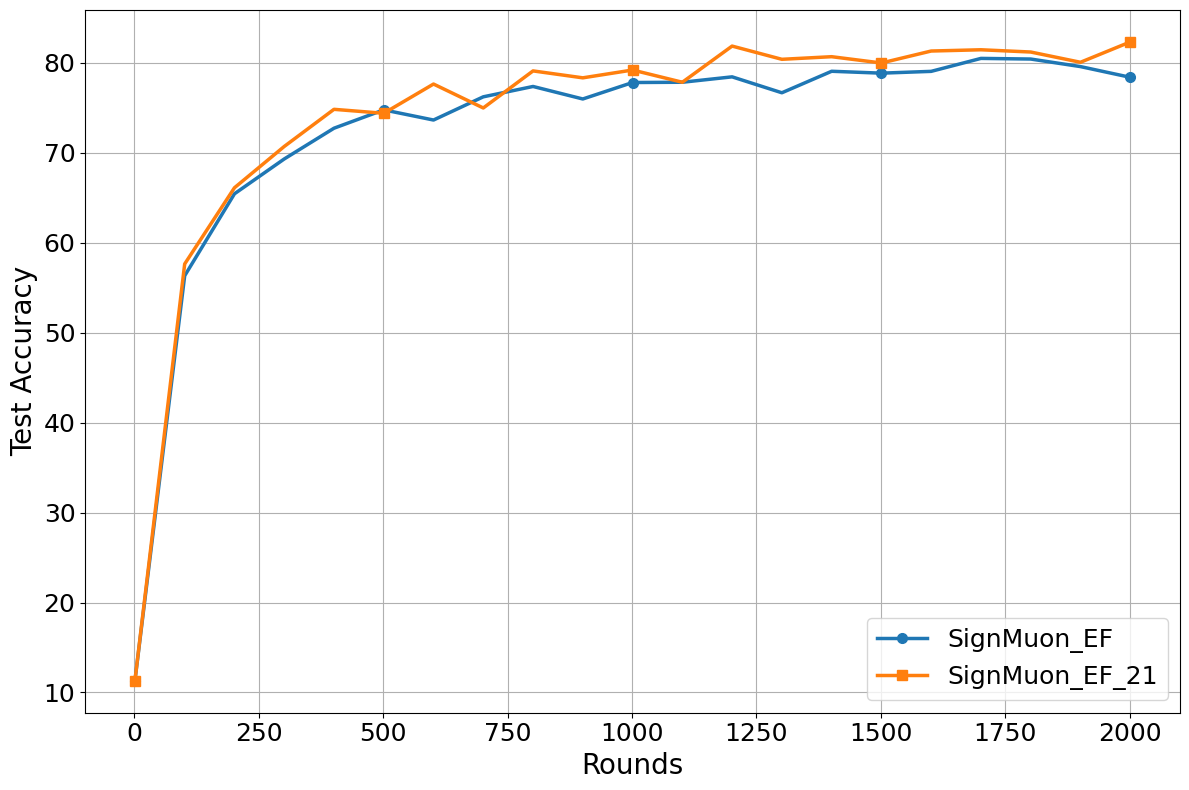

In [18]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_homo_cnn2_r2000_c10_s3",
        "saves_federated/v3_after_renew/fed_cifar10_signmuon_ef_21_homo_cnn2_r2000_c10_s3",
    ],
    labels=[
        "SignMuon_EF",
        "SignMuon_EF_21",
    ],
    metric="test_acc",
    title="CIFAR10 test loss",
)